In [35]:
import math 
import numpy as np 
import matplotlib.pyplot as plt

In [36]:
# --- physical properties ---
rho = 1000       # kg/m3
g = 9.81         # m/s2
mu = 1e-3        # Pa·s

# --- permeability ---
k_intrinsic = 1e-12   # m2 (FIXED: realistic!)
K = k_intrinsic * rho * g / mu   # hydraulic conductivity

# --- geometry ---
r_sample = 0.01   # m
r_pipe   = 0.005  # m
L        = 0.1    # m

# --- experiment input ---
V_added = 1e-4   # m3 (100 mL)

# --- time ---
t_end = 60000
dt = 0.1   # FIXED: smaller timestep

In [37]:
def falling_head(
    t_end,
    dt,
    K,
    r_sample,
    r_pipe,
    L,
    V_added
):

    t = np.arange(0, t_end + dt, dt)

    h = np.zeros_like(t)
    Q = np.zeros_like(t)
    v = np.zeros_like(t)

    # areas
    A_sample = math.pi * r_sample**2
    A_pipe   = math.pi * r_pipe**2

    # initial head from volume
    h[0] = V_added / A_pipe

    for i in range(1, len(t)):

        # Darcy flow
        Q[i-1] = K * A_sample * h[i-1] / L

        # velocity
        v[i-1] = Q[i-1] / A_sample

        # head decay
        dhdt = -Q[i-1] / A_pipe

        # update (stable)
        h[i] = max(h[i-1] + dhdt * dt, 0)

    return t, h, Q, v

In [38]:
t, h, Q, v = falling_head(
    t_end,
    dt,
    K,
    r_sample,
    r_pipe,
    L,
    V_added
)

In [39]:
Q

array([3.92400000e-08, 3.92384602e-08, 3.92369205e-08, ...,
       2.33632459e-18, 2.33623292e-18, 0.00000000e+00], shape=(600001,))

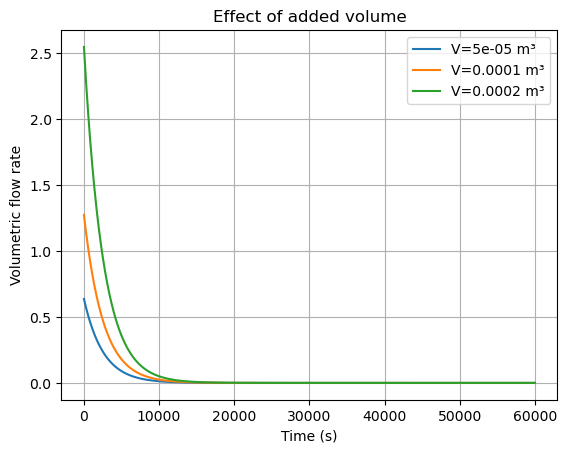

In [41]:
volumes = [5e-5, 1e-4, 2e-4]

plt.figure()

for V in volumes:
    t, Q, _, _ = falling_head(t_end, dt, K, r_sample, r_pipe, L, V)
    plt.plot(t, Q, label=f"V={V} m³")

plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Volumetric flow rate")
plt.title("Effect of added volume")
plt.grid()
plt.savefig("added_water_volume_Q_time_effect.png", dpi=300)
plt.show()

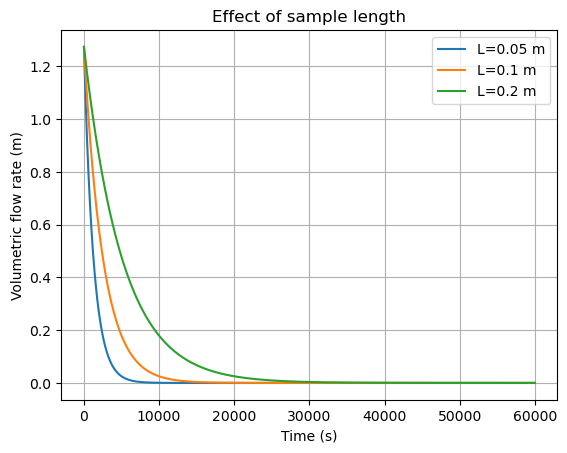

In [ ]:
lengths = [0.05, 0.1, 0.2]

plt.figure()

for L_val in lengths:
    t, Q, _, _ = falling_head(t_end, dt, K, r_sample, r_pipe, L_val, V_added)
    plt.plot(t, Q, label=f"L={L_val} m")

plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Volumetric flow rate (m)")
plt.title("Effect of sample length")
plt.grid()
plt.savefig("sample_length_Q_time_effect.png",dpi=300)
plt.show()

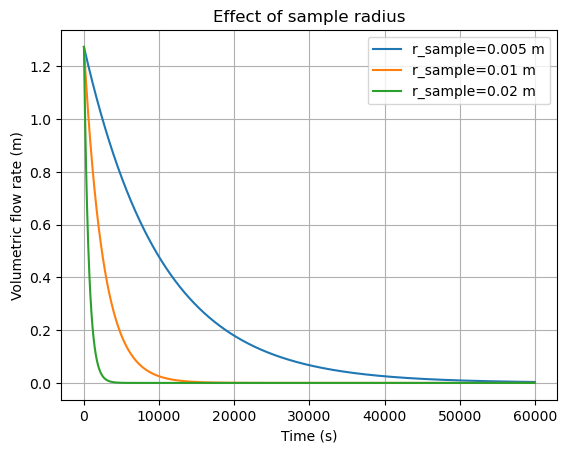

In [ ]:
radii = [0.005, 0.01, 0.02]

plt.figure()

for r in radii:
    t, Q, _, _ = falling_head(t_end, dt, K, r, r_pipe, L, V_added)
    plt.plot(t, Q, label=f"r_sample={r} m")

plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Volumetric flow rate (m)")
plt.title("Effect of sample radius")
plt.grid()
plt.savefig("sample_radius_Q_time_effect",dpi=300)
plt.show()